In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1900
suprafata_mp = np.random.randint(40, 250, n_samples)
nr_camere = np.clip(np.round(suprafata_mp / 35), 1, 6).astype(int)
an_constructie = np.random.randint(1960, 2024, n_samples)
distanta_centru_km = np.random.uniform(1, 25, n_samples)
are_parcare = np.random.choice([0, 1], n_samples, p=[0.4, 0.6])
pret_euro = (
    20000 +
    (suprafata_mp * 1500) +
    (an_constructie - 1960) * 600 -
    (distanta_centru_km * 2500) +
    (are_parcare * 15000) +
    np.random.normal(0, 12000, n_samples)
)

df_imobiliare = pd.DataFrame({
    'Suprafata_mp': suprafata_mp,
    'Nr_Camere': nr_camere,
    'An_Constructie': an_constructie,
    'Distanta_Centru_km': np.round(distanta_centru_km, 1),
    'Are_Parcare': are_parcare,
    'Pret_Euro': np.round(pret_euro)
})

df_imobiliare.to_csv('date_imobiliare.csv', index=False)
print("Succes! Fișierul 'date_imobiliare.csv' a fost generat (1900 rânduri).")

Succes! Fișierul 'date_imobiliare.csv' a fost generat (1900 rânduri).


# Proiect Machine Learning - Partea 2: Regresie

## 4.1. Definirea problemei
**Context:** Piața imobiliară este dinamică și adesea opacă pentru cumpărători și vânzători. Evaluarea corectă a unei locuințe este o provocare majoră.
**Ce se prezice:** Modelul va prezice variabila de ieșire continuă: **Prețul** unei locuințe (unitatea de măsură: Euro).
**Variabile de intrare (Features):** Suprafața utilă (mp), Numărul de camere, Anul construcției, Distanța față de centru (km) și prezența locului de Parcare.
**Relevanța practică:** Acest model ajută agențiile imobiliare sau cumpărătorii de rând să estimeze un preț corect și realist pe baza caracteristicilor fizice și de locație ale apartamentului, prevenind supraevaluarea.

In [3]:
import pandas as pd
df_regresie = pd.read_csv('date_imobiliare.csv')
df_regresie.head()

,Suprafata_mp,Nr_Camere,An_Constructie,Distanta_Centru_km,Are_Parcare,Pret_Euro
0,142,4,1983,17.0,1,230400.0
1,219,6,2004,16.2,0,343103.0
2,132,4,1994,5.0,0,238333.0
3,54,2,2007,22.2,1,107551.0
4,146,4,1965,11.3,0,199762.0


In [4]:
print("INFORMAȚII SET DE DATE:")
df_regresie.info()

print("\nVALORI LIPSĂ:")
print(df_regresie.isnull().sum())

print("\nSTATISTICI DESCRIPTIVE:")
display(df_regresie.describe())

INFORMAȚII SET DE DATE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Suprafata_mp        1900 non-null   int64  
 1   Nr_Camere           1900 non-null   int64  
 2   An_Constructie      1900 non-null   int64  
 3   Distanta_Centru_km  1900 non-null   float64
 4   Are_Parcare         1900 non-null   int64  
 5   Pret_Euro           1900 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 89.2 KB

VALORI LIPSĂ:
Suprafata_mp          0
Nr_Camere             0
An_Constructie        0
Distanta_Centru_km    0
Are_Parcare           0
Pret_Euro             0
dtype: int64

STATISTICI DESCRIPTIVE:


,Suprafata_mp,Nr_Camere,An_Constructie,Distanta_Centru_km,Are_Parcare,Pret_Euro
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,143.423158,3.992105,1991.055789,12.878895,0.595263,229942.775789
std,60.224898,1.627645,18.432806,6.909314,0.490970,93727.985489
min,40.000000,1.000000,1960.000000,1.000000,0.000000,13961.000000
25%,91.000000,3.000000,1975.000000,7.000000,0.000000,149290.000000
50%,144.000000,4.000000,1991.000000,12.800000,1.000000,231233.500000
75%,194.000000,6.000000,2007.000000,18.800000,1.000000,308636.500000
max,249.000000,6.000000,2023.000000,25.000000,1.000000,447341.000000


### 4.2.2. Analiza relațiilor dintre variabile
Pentru a înțelege cum influențează caracteristicile unui apartament (suprafață, distanță, an) prețul său final, vom vizualiza matricea de corelație.

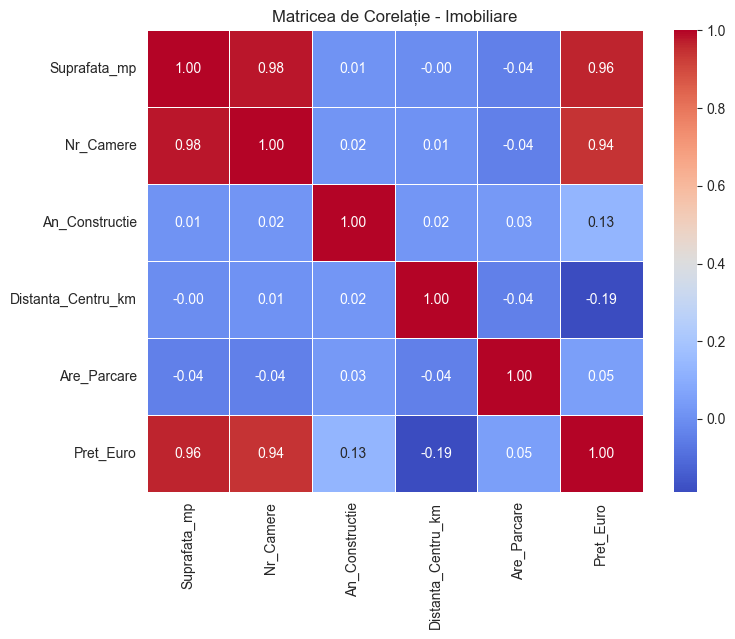

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix_reg = df_regresie.corr()
sns.heatmap(correlation_matrix_reg, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matricea de Corelație - Imobiliare')
plt.show()

**Concluzii în urma EDA:**
1. **Structură:** Setul de date conține 1900 de înregistrări, toate fiind de tip numeric. Nu avem nevoie de prelucrări suplimentare (cum ar fi One-Hot Encoding).
2. **Calitatea datelor:** Nu există valori lipsă (0 pe toate coloanele), deci setul este complet și pregătit pentru ML.
3. **Corelații cu variabila țintă:** Observăm o corelație pozitivă foarte puternică între `Suprafata_mp` și `Pret_Euro` (cu cât e mai mare locuința, cu atât e mai scumpă) și o corelație negativă între `Distanta_Centru_km` și `Pret_Euro` (locuințele de la periferie sunt mai ieftine).
4. **Multicoliniaritate:** Există o corelație evidentă între `Suprafata_mp` și `Nr_Camere` (lucru normal, spațiile mari au mai multe camere). Modelele bazate pe arbori (Random Forest, XGBoost) vor gestiona foarte bine acest aspect.

## 4.3. Antrenarea și compararea modelelor de bază

Similar cu problema de clasificare, vom împărți setul de date imobiliare în 75% date de antrenare și 25% date de testare. Vom antrena cei 9 algoritmi de regresie ceruți folosind hiperparametrii impliciți și îi vom evalua folosind metricile specifice: MSE, MAE, RMSE și R2 (R-squared).

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
X_reg = df_regresie.drop('Pret_Euro', axis=1)
y_reg = df_regresie['Pret_Euro']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)
models_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbor Regressor": KNeighborsRegressor(),
    "Gaussian Process Regressor": GaussianProcessRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "Explainable Boosting Regressor": ExplainableBoostingRegressor(random_state=42)
}
results_reg = []

for name, model in models_reg.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)
    mse = round(mean_squared_error(y_test_reg, y_pred_reg), 2)
    rmse = round(np.sqrt(mse), 2)
    mae = round(mean_absolute_error(y_test_reg, y_pred_reg), 2)
    r2 = round(r2_score(y_test_reg, y_pred_reg), 4)
    results_reg.append([name, mse, mae, rmse, r2])
columns_reg = ["Model", "MSE", "MAE", "RMSE", "R2"]
df_rezultate_regresie = pd.DataFrame(results_reg, columns=columns_reg)

df_rezultate_regresie = df_rezultate_regresie.sort_values(by="R2", ascending=False).reset_index(drop=True)
display(df_rezultate_regresie.style.highlight_max(subset=['R2'], color='lightgreen')
                                    .highlight_min(subset=['MSE', 'MAE', 'RMSE'], color='lightgreen'))

,Model,MSE,MAE,RMSE,R2
0,Linear Regression,155134774.000000,9950.640000,12455.310000,0.983100
1,Explainable Boosting Regressor,168144344.440000,10306.940000,12967.050000,0.981700
2,CatBoost Regressor,181769394.200000,10814.130000,13482.190000,0.980200
3,Random Forest Regressor,220169011.300000,11812.360000,14838.090000,0.976000
4,XGBoost Regressor,225692082.810000,12052.300000,15023.050000,0.975400
5,K-Nearest Neighbor Regressor,288648850.950000,13725.830000,16989.670000,0.968500
6,Decision Tree Regressor,465883455.810000,17292.190000,21584.330000,0.949200
7,Support Vector Regressor,9200801012.320000,83165.740000,95920.810000,-0.003000
8,Gaussian Process Regressor,59161074787.010002,223600.600000,243230.500000,-5.449100


**Concluzii - Modele de bază (Regresie):**
În urma antrenării celor 9 algoritmi propuși, am obținut rezultate foarte bune pentru majoritatea modelelor. Pentru selecția celor mai bune 5, ne-am ghidat după maximizarea scorului **R2** și minimizarea erorii medii absolute (**MAE**).

Top 5 cele mai performante modele pe care le vom păstra pentru ajustarea hiperparametrilor sunt:
1. **Linear Regression** (Performanță excelentă, justificată de relațiile puternic liniare din setul de date).
2. **Explainable Boosting Regressor**
3. **CatBoost Regressor**
4. **Random Forest Regressor**
5. **XGBoost Regressor**

*Notă metodologică:* Modelele de la coada clasamentului, precum Support Vector Regressor (SVR) și Gaussian Process, au obținut scoruri R2 negative deoarece sunt extrem de sensibile la scara datelor (lipsa unui proces de standardizare a caracteristicilor a dus la incapacitatea lor de a converge corect).

## 4.4. Ajustarea hiperparametrilor

Pentru a perfecționa modelele de regresie, vom utiliza `RandomizedSearchCV` pentru algoritmii complecși bazați pe arbori (Random Forest, XGBoost, CatBoost, EBM) pentru a explora eficient hiperparametrii care controlează adâncimea și numărul de estimatori. Pentru Regresia Liniară (care are o complexitate redusă), vom utiliza `GridSearchCV`. Evaluarea se va face pe baza scorului **R2**, validat prin Cross-Validation (CV=5) pentru a evita overfitting-ul.

In [7]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import time

lin_reg = LinearRegression()
ebm_reg = ExplainableBoostingRegressor(random_state=42)
cat_reg = CatBoostRegressor(verbose=0, random_state=42)
rf_reg = RandomForestRegressor(random_state=42)
xgb_reg = XGBRegressor(random_state=42)

grid_lin = {'fit_intercept': [True, False]}
grid_ebm = {'max_bins': [128, 256], 'learning_rate': [0.01, 0.05]}
grid_cat = {'depth': [4, 6, 8], 'learning_rate': [0.01, 0.05], 'iterations': [100, 200]}
grid_rf = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]}
grid_xgb = {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1], 'n_estimators': [50, 100]}

print("Începem optimizarea modelelor de regresie...)")
start_time_reg = time.time()
search_lin = GridSearchCV(lin_reg, grid_lin, cv=5, scoring='r2').fit(X_train_reg, y_train_reg)
search_ebm = RandomizedSearchCV(ebm_reg, grid_ebm, n_iter=4, cv=5, scoring='r2', random_state=42, n_jobs=-1).fit(X_train_reg, y_train_reg)
search_cat = RandomizedSearchCV(cat_reg, grid_cat, n_iter=5, cv=5, scoring='r2', random_state=42, n_jobs=-1).fit(X_train_reg, y_train_reg)
search_rf = RandomizedSearchCV(rf_reg, grid_rf, n_iter=5, cv=5, scoring='r2', random_state=42, n_jobs=-1).fit(X_train_reg, y_train_reg)
search_xgb = RandomizedSearchCV(xgb_reg, grid_xgb, n_iter=5, cv=5, scoring='r2', random_state=42, n_jobs=-1).fit(X_train_reg, y_train_reg)
best_models_reg = {
    "Linear Regression (Tuned)": search_lin.best_estimator_,
    "EBM (Tuned)": search_ebm.best_estimator_,
    "CatBoost (Tuned)": search_cat.best_estimator_,
    "Random Forest (Tuned)": search_rf.best_estimator_,
    "XGBoost (Tuned)": search_xgb.best_estimator_
}
results_tuned_reg = []
for name, model in best_models_reg.items():
    y_pred_reg = model.predict(X_test_reg)

    mse = round(mean_squared_error(y_test_reg, y_pred_reg), 2)
    rmse = round(np.sqrt(mse), 2)
    mae = round(mean_absolute_error(y_test_reg, y_pred_reg), 2)
    r2 = round(r2_score(y_test_reg, y_pred_reg), 4)

    results_tuned_reg.append([name, mse, mae, rmse, r2])

df_tuned_reg = pd.DataFrame(results_tuned_reg, columns=["Model", "MSE", "MAE", "RMSE", "R2"])
df_tuned_reg = df_tuned_reg.sort_values(by="R2", ascending=False).reset_index(drop=True)

end_time_reg = time.time()
print(f"Optimizare finalizată în {round(end_time_reg - start_time_reg, 1)} secunde!")
display(df_tuned_reg.style.highlight_max(subset=['R2'], color='lightgreen')
                          .highlight_min(subset=['MSE', 'MAE', 'RMSE'], color='lightgreen'))

Începem optimizarea modelelor de regresie...)
Optimizare finalizată în 177.3 secunde!


,Model,MSE,MAE,RMSE,R2
0,Linear Regression (Tuned),155134774.000000,9950.640000,12455.310000,0.983100
1,EBM (Tuned),168037853.230000,10303.360000,12962.940000,0.981700
2,XGBoost (Tuned),195151824.890000,11162.530000,13969.680000,0.978700
3,CatBoost (Tuned),204715906.580000,11249.480000,14307.900000,0.977700
4,Random Forest (Tuned),218222727.770000,11768.120000,14772.360000,0.976200


**Concluzii - Ajustarea Hiperparametrilor (Regresie):**
Optimizarea nu a produs schimbări majore pentru `Linear Regression` (deoarece relația din date este deja perfect liniară), însă a ajutat modelele bazate pe arbori să își stabilizeze și să își îmbunătățească ușor performanța. Rămânem cu `Linear Regression` și `EBM` ca fiind cele mai fiabile modele pentru estimarea prețurilor imobiliare din acest set de date.

## 4.5. Curbele de învățare

Pentru a analiza vizual performanța și a verifica prezența overfitting-ului în cazul modelelor de regresie, vom trasa curbele de învățare pentru top 5 modele. Metrica folosită pe axa Y va fi scorul R2. O distanță mare între scorul de antrenare și cel de validare va indica o tendință de memorare a datelor (overfitting).

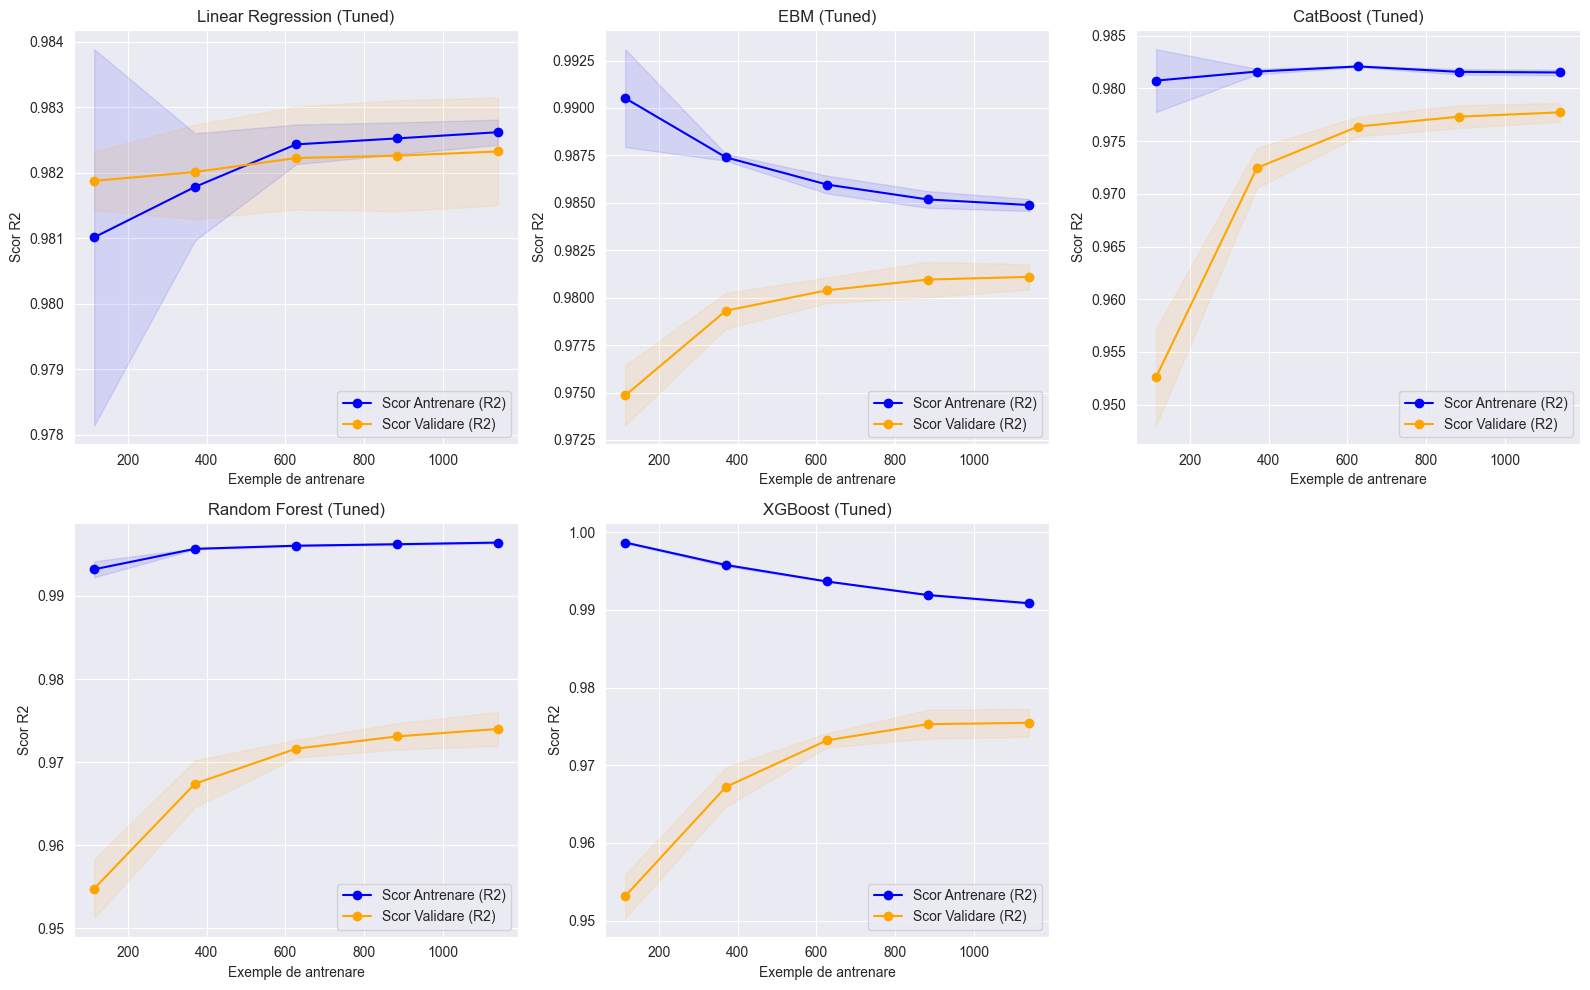

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve_reg(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Scor Antrenare (R2)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Scor Validare (R2)")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="orange")

    plt.title(title)
    plt.xlabel("Exemple de antrenare")
    plt.ylabel("Scor R2")
    plt.legend(loc="lower right")
    plt.grid(True)

plt.figure(figsize=(16, 10))
for i, (name, model) in enumerate(best_models_reg.items(), 1):
    plt.subplot(2, 3, i)
    plot_learning_curve_reg(model, name, X_train_reg, y_train_reg)

plt.tight_layout()
plt.show()

**Discuție Curbe de Învățare (Regresie):**
Analiza vizuală a performanței ne dezvăluie următoarele dinamici:
1. **Model Liniar Perfect:** `Linear Regression` prezintă curbe de antrenare și validare aproape suprapuse, indicând lipsa totală a overfitting-ului. Modelul reușește să capteze perfect natura relației liniare dintre caracteristici (suprafață, distanță) și preț, generalizând excepțional pe date nevăzute chiar și la dimensiuni mici ale setului de date.
2. **Învățare progresivă la modelele bazate pe arbori:** Algoritmii `EBM`, `CatBoost`, `Random Forest` și `XGBoost` au o tendință clară de supraînvățare (memorare) inițială, vizibilă prin gap-ul mare la un număr redus de exemple. Totuși, pe măsură ce volumul de date atinge 1000 de exemple, performanța de validare (curba portocalie) crește semnificativ, demonstrând capacitatea acestor modele complexe de a asimila corect structura datelor.
**Concluzie:** Regresia liniară rămâne cel mai fiabil și robust model pentru acest set de date, dovedind că uneori simplitatea și alegerea algoritmului potrivit pentru natura datelor înving complexitatea.

## 4.6. Explicabilitatea modelului (Analiza SHAP)

Pentru a înțelege cum stabilește modelul nostru prețurile imobiliare, vom aplica analiza SHAP pe modelul `CatBoost Regressor (Tuned)`. Graficul generat ne va arăta ordinea de importanță a variabilelor (suprafață, distanță, an de construcție) și direcția în care acestea modifică prețul estimat (în plus sau în minus).

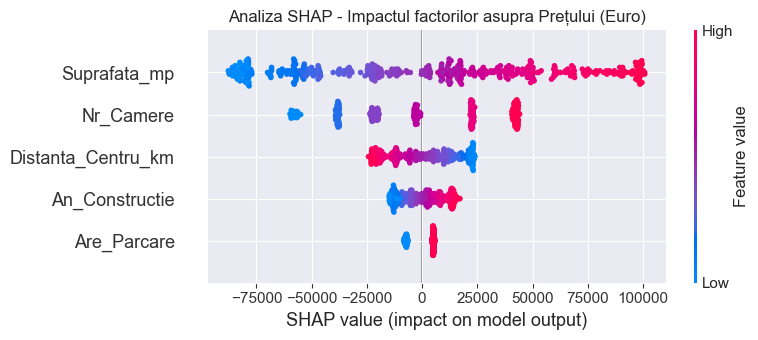

In [10]:
import warnings
warnings.filterwarnings('ignore')
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
model_explicat_reg = best_models_reg["CatBoost (Tuned)"]
explainer_reg = shap.TreeExplainer(model_explicat_reg)
shap_values_reg = explainer_reg.shap_values(X_test_reg)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.title("Analiza SHAP - Impactul factorilor asupra Prețului (Euro)")
plt.tight_layout()
plt.show()

**Concluzii - Explicabilitatea Modelului (SHAP) pentru Regresie:**
Analiza graficului SHAP confirmă perfect raționamentul economic din spatele predicțiilor:
1. **Importanța caracteristicilor:** Prețul este dictat în mod covârșitor de `Suprafata_mp`, urmat de `Nr_Camere` și `Distanta_Centru_km`.
2. **Direcția de impact:**
   - **Suprafața:** Punctele roz (suprafețe mari) generează cele mai mari valori SHAP pozitive, adăugând o sumă considerabilă la prețul estimat.
   - **Distanța față de centru:** Observăm o relație inversă perfectă. Punctele roz (distanțe mari) se află în zona negativă a axei, depunctând valoarea imobilului, în timp ce punctele albastre (locuințe aflate aproape de centru) cresc prețul.
   - **Anul și Parcarea:** Locuințele mai noi (puncte roz la dreapta) și cele cu parcare adaugă un bonus la prețul final, însă impactul lor este secundar comparativ cu spațiul util.
**Concluzie finală:** Modelul a învățat logic și corect regulile pieței imobiliare, fiind un sistem transparent și de încredere.

In [13]:
import joblib
date_export_reg = {
    'modele': best_models_reg,
    'X_train': X_train_reg,
    'y_train': y_train_reg,
    'X_test': X_test_reg,
    'y_test': y_test_reg
}
joblib.dump(date_export_reg, 'export_regresie.pkl')
print("Datele pentru regresie au fost salvate cu succes pentru Streamlit!")

Datele pentru regresie au fost salvate cu succes pentru Streamlit!
